# Week 1: Autoregressive Model with Exogenous Inputs (ARX)

**Notebook goal:** Implement a classical econometric baseline that follows the shared abstract class and uses the local `Quants data` files.

## Why ARX for Week 1?

ARX extends an autoregressive model by adding macroeconomic exogenous variables:

$$
y_t = c + \sum_{i=1}^{p} a_i y_{t-i} + \sum_{j=0}^{b} \mathbf{B}_j^\top \mathbf{x}_{t-j} + \varepsilon_t
$$

- $y_t$: wheat futures price at time \(t\)
- $x_t$: exogenous FRED-MD feature vector at time \(t\)
- \(p\): number of AR lags
- \(b\): number of exogenous lags

This model is a strong **classical benchmark** before deep models.

## Design choices used in this notebook

1. Follow the `VIP_Abstract_Class.ipynb` interface (`fit`, `predict`, `evaluate`, `save`, `load`).
2. Use chronological split (80/20) for time-series validity.


In [3]:
# Core imports
from abc import ABC, abstractmethod
from pathlib import Path
import warnings
import pickle

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Imports loaded.")

Imports loaded.


## Metrics from Survey of Commodity Price Forecasting

This notebook records the point-forecast metrics highlighted in the survey:

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{t=1}^n (y_t - \hat y_t)^2}, \quad
\text{MAE} = \frac{1}{n}\sum_{t=1}^n |y_t - \hat y_t|
$$

$$
\text{MAPE} = \frac{100}{n}\sum_{t=1}^n \left|\frac{y_t - \hat y_t}{y_t}\right|,
\quad
\text{MASE} = \frac{\frac{1}{n}\sum |y_t-\hat y_t|}{\frac{1}{n-1}\sum |y_t-y_{t-1}|}
$$

$$
\text{RRMSE} = \frac{\text{RMSE}}{\bar y}
$$


In [4]:
# ============================================================
# Base abstract class (same template contract as VIP notebook)
# ============================================================

class BaseForecastModel(ABC):
    """Simple base class for forecasting models."""

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass


# ============================================================
# Metric helpers
# ============================================================

def naive_persistence_forecast(y_train: np.ndarray, y_test: np.ndarray) -> np.ndarray:
    y_pred = np.empty_like(y_test, dtype=float)
    y_pred[0] = y_train[-1]
    y_pred[1:] = y_test[:-1]
    return y_pred


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_train_for_mase: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    with np.errstate(divide="ignore", invalid="ignore"):
        mape_vals = np.abs((y_true - y_pred) / y_true)
        mape = float(np.nanmean(mape_vals[np.isfinite(mape_vals)]) * 100.0)

    naive_scale = np.mean(np.abs(np.diff(np.asarray(y_train_for_mase, dtype=float))))
    mase = float(mae / naive_scale) if naive_scale > 0 else np.nan

    y_mean = np.mean(y_true)
    rrmse = float(rmse / y_mean) if y_mean != 0 else np.nan

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "mase": mase,
        "rrmse": rrmse,
        "r2": r2,
    }


# ============================================================
# ARX model implementation
# ============================================================

class ARXForecastModel(BaseForecastModel):
    """
    ARX using closed-form Ridge/OLS:
      y = intercept + Z @ coef

    Z is built from lagged endogenous price + lagged exogenous features.
    """

    def __init__(
        self,
        task_type: str = "regression",
        ar_lags: int = 5,
        exog_lags: int = 3,
        alpha: float = 1.0,
        n_exog_features: int = 31,
    ):
        super().__init__(
            task_type=task_type,
            ar_lags=ar_lags,
            exog_lags=exog_lags,
            alpha=alpha,
            n_exog_features=n_exog_features,
        )
        self.ar_lags = ar_lags
        self.exog_lags = exog_lags
        self.alpha = alpha
        self.n_exog_features = n_exog_features

        self.coef_ = None
        self.intercept_ = None
        self.x_scaler_ = None
        self.y_scaler_ = None
        self.y_train_original_ = None

    def _fit_scalers(self, X_3d: np.ndarray, y: np.ndarray):
        n_features = X_3d.shape[2]
        self.x_scaler_ = StandardScaler().fit(X_3d.reshape(-1, n_features))
        self.y_scaler_ = StandardScaler().fit(y.reshape(-1, 1))

    def _scale_X(self, X_3d: np.ndarray) -> np.ndarray:
        n_features = X_3d.shape[2]
        X_scaled = self.x_scaler_.transform(X_3d.reshape(-1, n_features))
        return X_scaled.reshape(X_3d.shape)

    def _scale_y(self, y: np.ndarray) -> np.ndarray:
        return self.y_scaler_.transform(y.reshape(-1, 1)).ravel()

    def _inverse_y(self, y_scaled: np.ndarray) -> np.ndarray:
        return self.y_scaler_.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

    def _build_regressor_matrix(self, X_3d_scaled: np.ndarray) -> np.ndarray:
        # Last column is Price, first n_exog_features columns are exogenous.
        price_lags = X_3d_scaled[:, -self.ar_lags:, -1]
        exog_lags = X_3d_scaled[:, -self.exog_lags:, : self.n_exog_features]
        exog_flat = exog_lags.reshape(X_3d_scaled.shape[0], -1)
        return np.concatenate([price_lags, exog_flat], axis=1)

    def _ridge_closed_form(self, Z: np.ndarray, y_scaled: np.ndarray) -> np.ndarray:
        n_samples, n_reg = Z.shape
        Zb = np.column_stack([np.ones(n_samples), Z])
        A = Zb.T @ Zb
        A += self.alpha * np.eye(n_reg + 1)
        A[0, 0] -= self.alpha  # do not regularize intercept
        b = Zb.T @ y_scaled
        w = np.linalg.solve(A, b)
        return w

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.y_train_original_ = np.asarray(y_train, dtype=float).copy()

        self._fit_scalers(X_train, y_train)
        X_s = self._scale_X(X_train)
        y_s = self._scale_y(y_train)

        Z = self._build_regressor_matrix(X_s)
        w = self._ridge_closed_form(Z, y_s)

        self.intercept_ = float(w[0])
        self.coef_ = w[1:]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.coef_ is None:
            raise ValueError("Model not trained. Call fit() first.")

        X_s = self._scale_X(X)
        Z = self._build_regressor_matrix(X_s)
        y_s = Z @ self.coef_ + self.intercept_
        return self._inverse_y(y_s)

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray):
        y_pred = self.predict(X_test)
        return regression_metrics(
            y_true=np.asarray(y_test, dtype=float),
            y_pred=y_pred,
            y_train_for_mase=self.y_train_original_,
        )

    def save(self, filepath: str):
        if self.coef_ is None:
            raise ValueError("No trained model to save.")

        payload = {
            "coef": self.coef_,
            "intercept": self.intercept_,
            "x_scaler": self.x_scaler_,
            "y_scaler": self.y_scaler_,
            "y_train_original": self.y_train_original_,
            "hyperparameters": self.hyperparameters,
        }
        with open(filepath, "wb") as f:
            pickle.dump(payload, f)

    def load(self, filepath: str):
        with open(filepath, "rb") as f:
            payload = pickle.load(f)

        self.coef_ = payload["coef"]
        self.intercept_ = payload["intercept"]
        self.x_scaler_ = payload["x_scaler"]
        self.y_scaler_ = payload["y_scaler"]
        self.y_train_original_ = payload["y_train_original"]

        hp = payload["hyperparameters"]
        self.hyperparameters = hp
        self.ar_lags = hp["ar_lags"]
        self.exog_lags = hp["exog_lags"]
        self.alpha = hp["alpha"]
        self.n_exog_features = hp["n_exog_features"]

        return self

print("Base class + ARX model ready.")

Base class + ARX model ready.


## Data and preprocessing setup

### Data sources

- Wheat futures prices: `Quants data/Quants /Investing.com/US Wheat Futures Historical Data_2018.csv`
- Wheat futures prices: `Quants data/Quants /Investing.com/US Wheat Futures Historical Data_2025.csv`
- Macroeconomic exogenous features: `Quants data/Quants /FredMD_Dataset/FRED.csv`

### Preprocessing pipeline

1. Parse and clean price files; merge into a single daily price series.
2. Load FRED-MD file and keep selected macro features.
3. Shift exogenous monthly data forward by one month to reduce look-ahead leakage.
4. Reindex to daily frequency and forward-fill monthly values.
5. Join exogenous panel with daily wheat prices.
6. Build rolling windows (`lookback=30`) and one-step-ahead target.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ============================================================
# Data loading and preprocessing helpers
# ============================================================


df1 = pd.read_csv('/content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2018.csv')
BASE_DIR = Path("/content/drive/MyDrive/Quants ")
INVESTING_DIR = BASE_DIR / "Investing.com"
FRED_DIR = BASE_DIR / "FredMD_Dataset"

WHEAT_2018 = INVESTING_DIR / "US Wheat Futures Historical Data_2018.csv"
WHEAT_2025 = INVESTING_DIR / "US Wheat Futures Historical Data_2025.csv"
FRED_CSV = FRED_DIR / "FRED.csv"

print("Using data paths:")
print(" -", WHEAT_2018)
print(" -", WHEAT_2025)
print(" -", FRED_CSV)

for p in [WHEAT_2018, WHEAT_2025, FRED_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"Missing expected file: {p}")


# 31 features used this semester (OILPRICEx excluded)
FRED_FEATURES = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS", "TB3MS",
    "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA", "TB3SMFFM", "TB6SMFFM",
    "T1YFFM", "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM", "EXSZUSx",
    "EXJPUSx", "EXUSUKx", "EXCAUSx", "PPICMM", "UMCSENTx"
]


def load_price_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").set_index("Date")
    df["Price"] = df["Price"].astype(str).str.replace(",", "", regex=False).astype(float)
    return df["Price"]


def load_and_merge_wheat_prices(path_2018: Path, path_2025: Path) -> pd.Series:
    p1 = load_price_csv(path_2018)
    p2 = load_price_csv(path_2025)

    # keep continuity and avoid one duplicate overlap row.
    merged = pd.concat([p1, p2.iloc[1:]], axis=0)
    merged = merged[~merged.index.duplicated(keep="last")].sort_index()
    merged.name = "Price"
    return merged


def load_fred_features(path: Path, selected_features: list[str]) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.dropna(how="all", axis=1)

    # Drop columns with missing data
    drop_cols = []
    for c in df.columns:
        if c == "Month":
            continue
        s = df[c].isna() | (df[c].astype(str).str.strip() == "")
        if s.any():
            drop_cols.append(c)

    df["Month"] = pd.to_datetime(df["Month"])
    df = df.set_index("Month").sort_index()
    df = df.drop(columns=drop_cols, errors="ignore")

    missing_required = [c for c in selected_features if c not in df.columns]
    if missing_required:
        raise ValueError(f"Missing required FRED features: {missing_required}")

    df = df[selected_features].copy()

    # Shift forward one month to reduce look-ahead leakage.
    shifted_index = df.index + pd.DateOffset(months=1)
    df.index = shifted_index

    # Convert monthly to daily via forward fill.
    daily_index = pd.date_range(df.index.min(), df.index.max() + pd.offsets.MonthEnd(0), freq="D")
    df_daily = df.reindex(daily_index).ffill()

    return df_daily


def build_sequences(df_all: pd.DataFrame, lookback: int = 30):
    data = df_all.values
    X, y = [], []

    for i in tqdm(range(len(data) - lookback), desc="Building rolling sequences"):
        X.append(data[i : i + lookback, :])
        y.append(data[i + lookback, -1])

    return np.array(X), np.array(y)


def chronological_split(X: np.ndarray, y: np.ndarray, test_ratio: float = 0.2):
    test_size = int(len(X) * test_ratio)
    return X[:-test_size], X[-test_size:], y[:-test_size], y[-test_size:]

print(f"Number of exogenous features used: {len(FRED_FEATURES)}")

Using data paths:
 - /content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2018.csv
 - /content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2025.csv
 - /content/drive/MyDrive/Quants /FredMD_Dataset/FRED.csv
Number of exogenous features used: 31


Merged panel shape: (4488, 32)
Date range: 2008-01-01 to 2025-01-31
Columns: 32 (exog + Price)


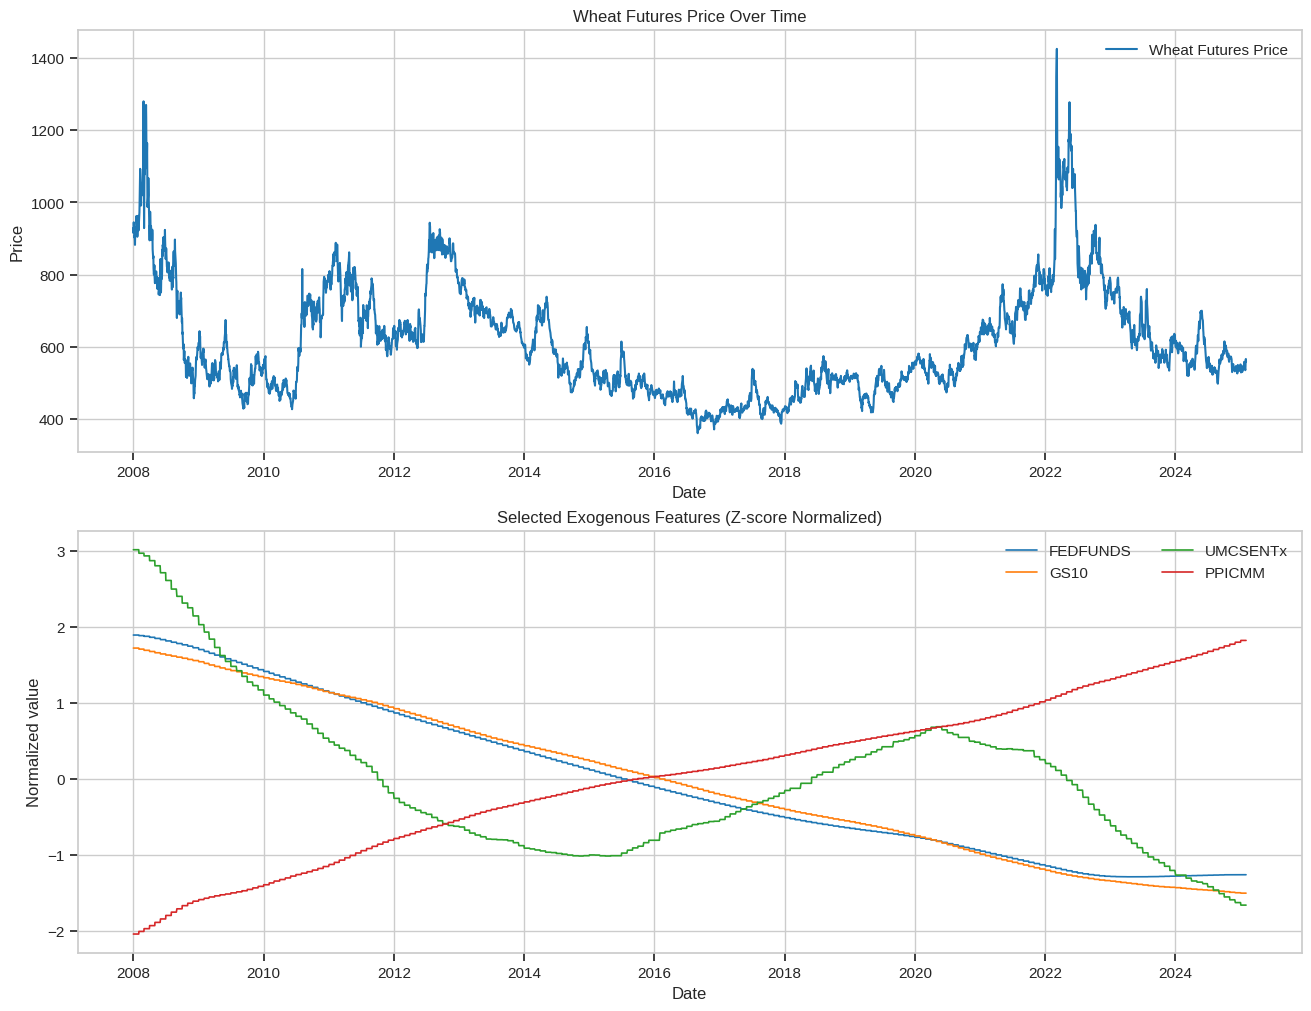

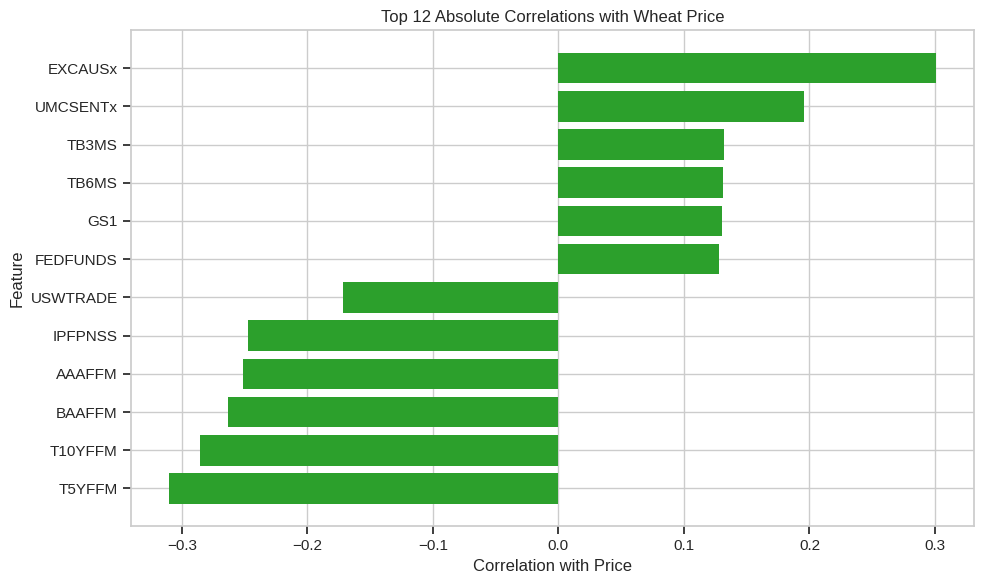

Top correlated features with Price:
          corr_price
T5YFFM     -0.310054
EXCAUSx     0.300521
T10YFFM    -0.285223
BAAFFM     -0.263376
AAAFFM     -0.250886
IPFPNSS    -0.246921
UMCSENTx    0.195353
USWTRADE   -0.171461
TB3MS       0.132267
TB6MS       0.131439
GS1         0.129978
FEDFUNDS    0.127950


In [7]:
# ============================================================
# Load and merge data
# ============================================================

df_price = load_and_merge_wheat_prices(WHEAT_2018, WHEAT_2025)
df_features = load_fred_features(FRED_CSV, FRED_FEATURES)

df_all = df_features.join(df_price, how="inner").dropna().sort_index()

# Consistency cutoff we used in previous semester
if pd.Timestamp("2008-01-01") in df_all.index or df_all.index.min() < pd.Timestamp("2008-01-01"):
    df_all = df_all.loc[pd.Timestamp("2008-01-01") :]

print("Merged panel shape:", df_all.shape)
print("Date range:", df_all.index.min().date(), "to", df_all.index.max().date())
print("Columns:", len(df_all.columns), "(exog + Price)")


# ============================================================
# Exploratory graphs
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(13, 10), constrained_layout=True)

# Graph 1: Wheat price over time
axes[0].plot(df_all.index, df_all["Price"], color="tab:blue", label="Wheat Futures Price")
axes[0].set_title("Wheat Futures Price Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper right")

# Graph 2: Selected normalized macro drivers (normalized for visual comparability)
compare_cols = ["FEDFUNDS", "GS10", "UMCSENTx", "PPICMM"]
compare_df = df_all[compare_cols].copy()
compare_df = (compare_df - compare_df.mean()) / compare_df.std(ddof=0)
for c in compare_cols:
    axes[1].plot(compare_df.index, compare_df[c], label=c, linewidth=1.2)

axes[1].set_title("Selected Exogenous Features (Z-score Normalized)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Normalized value")
axes[1].legend(loc="upper right", ncol=2)

plt.show()


# Graph 3: Correlation of exogenous features with Price
corr_with_price = df_all.corr(numeric_only=True)["Price"].drop("Price").sort_values(key=np.abs, ascending=False)
top_corr = corr_with_price.head(12).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_corr.index, top_corr.values, color="tab:green")
plt.title("Top 12 Absolute Correlations with Wheat Price")
plt.xlabel("Correlation with Price")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top correlated features with Price:")
print(corr_with_price.head(12).to_frame("corr_price"))

## Lag analysis diagnostics

This section adds classical lag-focused diagnostics often used for AR/ARX workflows:

1. **ACF/PACF** for wheat price (target) to inspect autoregressive memory.
2. **Cross-correlation vs lag** for top exogenous features.
3. **Validation RMSE heatmap** over `(ar_lags, exog_lags)` from the grid search (min over `alpha`).

These visuals complement (not replace) the final train/test forecast plots.

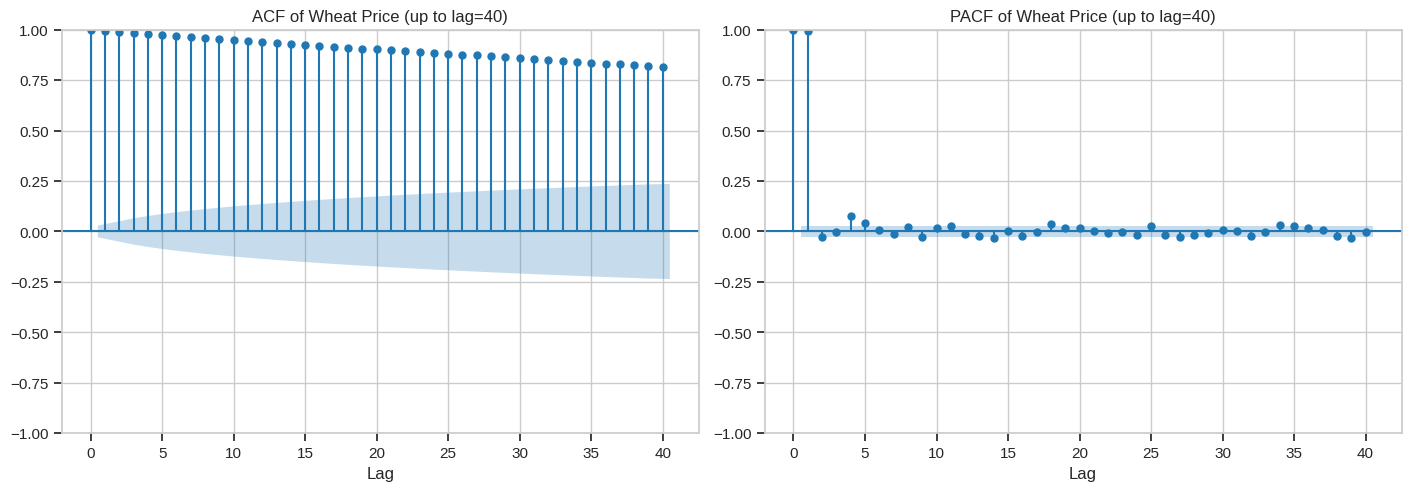

Top exogenous features selected for lag-correlation view: ['T5YFFM', 'EXCAUSx', 'T10YFFM', 'BAAFFM']


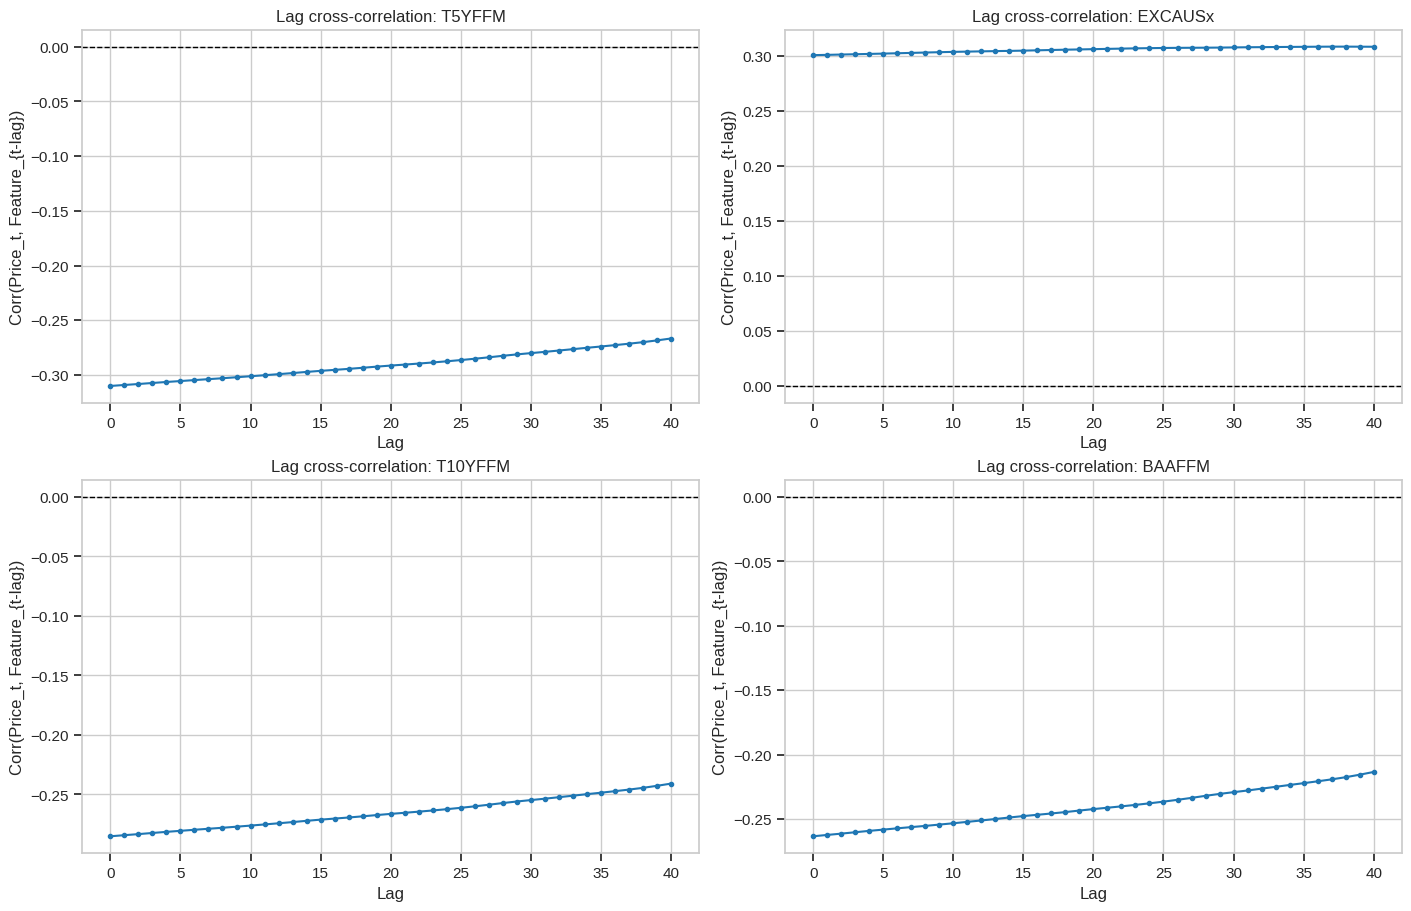

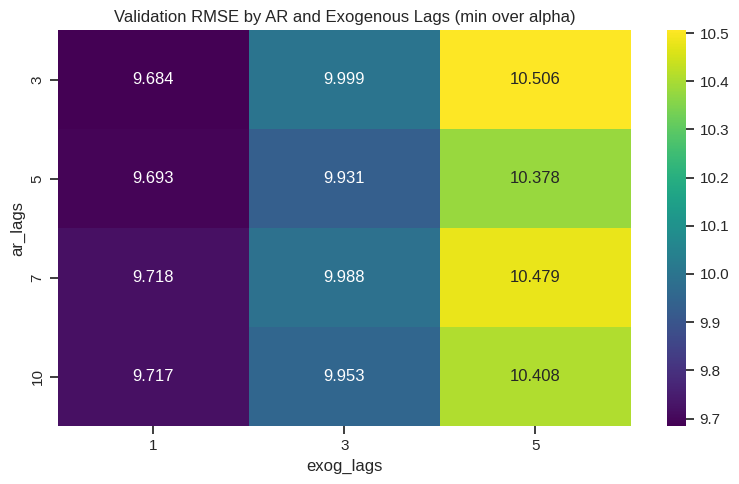

In [11]:
# ============================================================
# ACF / PACF + exogenous lag cross-correlation diagnostics
# ============================================================

# Optional dependency for ACF/PACF plotting
try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    _has_statsmodels = True
except Exception:
    _has_statsmodels = False
    print("statsmodels is not installed. Run: pip install statsmodels")

MAX_LAG = 40

# 1) ACF / PACF for target series
if _has_statsmodels:
    price_series = df_all["Price"].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
    plot_acf(price_series, lags=MAX_LAG, ax=axes[0])
    axes[0].set_title(f"ACF of Wheat Price (up to lag={MAX_LAG})")
    axes[0].set_xlabel("Lag")

    plot_pacf(price_series, lags=MAX_LAG, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF of Wheat Price (up to lag={MAX_LAG})")
    axes[1].set_xlabel("Lag")

    plt.show()

# 2) Cross-correlation by lag for top exogenous drivers
price = df_all["Price"].astype(float)
exog_df = df_all[FRED_FEATURES].astype(float)

# Pick top features by absolute contemporaneous correlation as candidates
top_n = 4
top_exog = (
    exog_df.corrwith(price)
    .abs()
    .sort_values(ascending=False)
    .head(top_n)
    .index
    .tolist()
)

print(f"Top exogenous features selected for lag-correlation view: {top_exog}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
axes = axes.flatten()

for i, feat in enumerate(top_exog):
    lag_corrs = []
    for lag in range(MAX_LAG + 1):
        # corr(y_t, x_{t-lag})
        c = price.corr(exog_df[feat].shift(lag))
        lag_corrs.append(c)

    ax = axes[i]
    ax.plot(range(MAX_LAG + 1), lag_corrs, marker="o", markersize=3)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Lag cross-correlation: {feat}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Corr(Price_t, Feature_{t-lag})")

for j in range(len(top_exog), len(axes)):
    axes[j].axis("off")

plt.show()

# 3) Grid-search lag heatmap (works after results_df is created)
if "results_df" in globals():
    heat = (
        results_df.groupby(["ar_lags", "exog_lags"], as_index=False)["val_rmse"]
        .min()
        .pivot(index="ar_lags", columns="exog_lags", values="val_rmse")
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Validation RMSE by AR and Exogenous Lags (min over alpha)")
    plt.xlabel("exog_lags")
    plt.ylabel("ar_lags")
    plt.tight_layout()
    plt.show()
else:
    print("Run the hyperparameter search cell first to plot lag heatmap.")

## Sequence construction and split

We use a 30-day lookback window:

- Input \(X_t\): previous 30 days of `[31 exogenous features + price]`
- Target \(y_t\): next-day wheat price

Then we keep time order and split chronologically:
- **Train:** first 80%
- **Test:** last 20%

This respects forecasting causality and avoids leakage from future samples.

Building rolling sequences:   0%|          | 0/4458 [00:00<?, ?it/s]

X shape: (4458, 30, 32)  | y shape: (4458,)
Train X: (3567, 30, 32)  | Test X: (891, 30, 32)

Naive persistence metrics:
     MSE: 414.960895
    RMSE: 20.370589
     MAE: 12.850842
    MAPE: 1.713910%
    MASE: 1.402173
   RRMSE: 0.028722
      R2: 0.984226


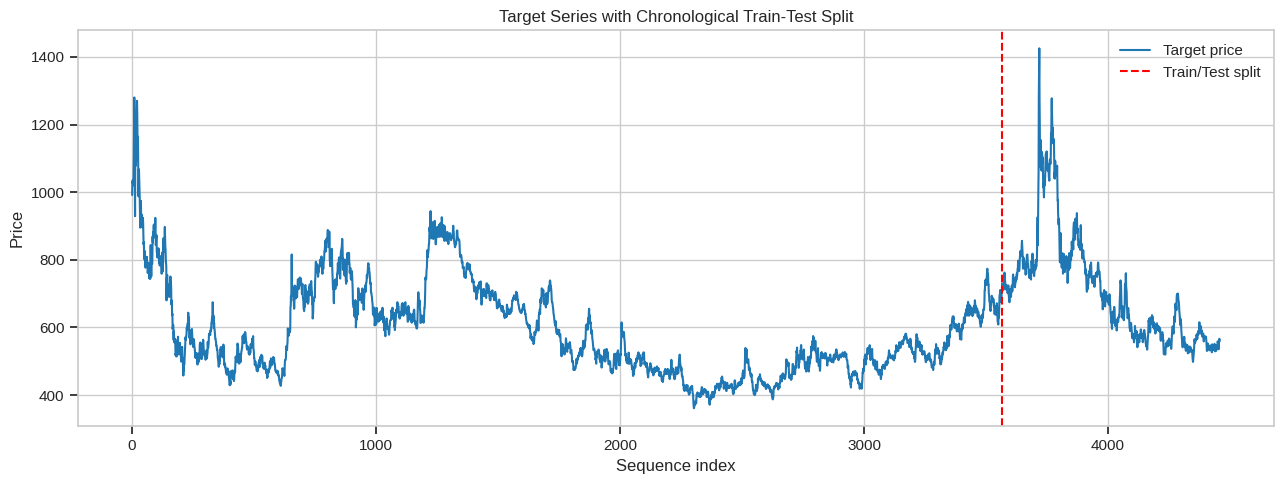

In [8]:
LOOKBACK = 30

X, y = build_sequences(df_all, lookback=LOOKBACK)
X_train, X_test, y_train, y_test = chronological_split(X, y, test_ratio=0.20)

print("X shape:", X.shape, " | y shape:", y.shape)
print("Train X:", X_train.shape, " | Test X:", X_test.shape)

# Baseline: naive persistence
naive_pred = naive_persistence_forecast(y_train, y_test)
naive_metrics = regression_metrics(y_test, naive_pred, y_train)

print("\nNaive persistence metrics:")
for k, v in naive_metrics.items():
    suffix = "%" if k == "mape" else ""
    print(f"  {k.upper():>6}: {v:.6f}{suffix}")

# Graph: train-test split on target series
split_idx = len(y_train)
all_target = np.concatenate([y_train, y_test])

plt.figure(figsize=(13, 5))
plt.plot(all_target, label="Target price", color="tab:blue")
plt.axvline(split_idx, color="red", linestyle="--", linewidth=1.5, label="Train/Test split")
plt.title("Target Series with Chronological Train-Test Split")
plt.xlabel("Sequence index")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

## Hyperparameter search

We tune a compact ARX search grid:

- `ar_lags` in {3, 5, 7, 10}
- `exog_lags` in {1, 3, 5}
- `alpha` in {0.0, 0.1, 1.0, 5.0}

Validation strategy:
- Last 20% of training set is used as a time-ordered validation segment.
- We optimize **validation RMSE**.

`alpha=0` corresponds to OLS (no regularization); larger `alpha` adds Ridge stabilization against multicollinearity.

In [13]:
# Time-ordered validation split from train set
val_ratio = 0.20
val_size = int(len(X_train) * val_ratio)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

search_space = {
    "ar_lags": [3, 5, 7, 10],
    "exog_lags": [1, 3, 5],
    "alpha": [0.0, 0.1, 1.0, 5.0],
}

results = []

combos = [
    (p, b, a)
    for p in search_space["ar_lags"]
    for b in search_space["exog_lags"]
    for a in search_space["alpha"]
]

for ar_lags, exog_lags, alpha in tqdm(combos, desc="ARX grid search"):
    model = ARXForecastModel(
        task_type="regression",
        ar_lags=ar_lags,
        exog_lags=exog_lags,
        alpha=alpha,
        n_exog_features=len(FRED_FEATURES),
    )
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)
    val_metrics = regression_metrics(y_val, y_val_pred, y_tr)

    row = {
        "ar_lags": ar_lags,
        "exog_lags": exog_lags,
        "alpha": alpha,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values("val_rmse").reset_index(drop=True)
print("Top 10 configurations by validation RMSE:")
display(results_df.head(10))

best_cfg = results_df.iloc[0]
print("\nSelected configuration:")
print(best_cfg[["ar_lags", "exog_lags", "alpha", "val_rmse", "val_mae", "val_mape", "val_mase", "val_rrmse", "val_r2"]])

ARX grid search:   0%|          | 0/48 [00:00<?, ?it/s]

Top 10 configurations by validation RMSE:


,ar_lags,exog_lags,alpha,val_mse,val_rmse,val_mae,val_mape,val_mase,val_rrmse,val_r2
0,3,1,5.0,93.785506,9.684292,7.298752,1.316823,0.755064,0.017556,0.981923
1,5,1,5.0,93.963622,9.693483,7.328784,1.319474,0.758170,0.017573,0.981888
2,10,1,5.0,94.419447,9.716967,7.336586,1.321126,0.758978,0.017615,0.981800
3,7,1,5.0,94.438788,9.717962,7.350378,1.324209,0.760404,0.017617,0.981797
4,5,3,5.0,98.621329,9.930827,7.718056,1.400121,0.798441,0.018003,0.980990
5,10,3,5.0,99.069670,9.953375,7.739103,1.404257,0.800618,0.018044,0.980904
6,7,3,5.0,99.766785,9.988332,7.779786,1.412734,0.804827,0.018107,0.980770
7,3,3,5.0,99.988205,9.999410,7.780269,1.415918,0.804877,0.018127,0.980727
8,5,1,1.0,102.045023,10.101734,7.931549,1.435966,0.820527,0.018313,0.980330
9,10,1,1.0,102.403315,10.119452,7.947610,1.439613,0.822189,0.018345,0.980261



Selected configuration:
ar_lags      3.000000
exog_lags    1.000000
alpha        5.000000
val_rmse     9.684292
val_mae      7.298752
val_mape     1.316823
val_mase     0.755064
val_rrmse    0.017556
val_r2       0.981923
Name: 0, dtype: float64



Final ARX test metrics:
     MSE: 440.657800
    RMSE: 20.991851
     MAE: 13.028243
    MAPE: 1.731707%
    MASE: 1.421530
   RRMSE: 0.029598
      R2: 0.983249

Naive vs ARX on test:


,model,mse,rmse,mae,mape,mase,rrmse,r2
0,Naive Persistence,414.960895,20.370589,12.850842,1.713910,1.402173,0.028722,0.984226
1,ARX (best),440.657800,20.991851,13.028243,1.731707,1.421530,0.029598,0.983249


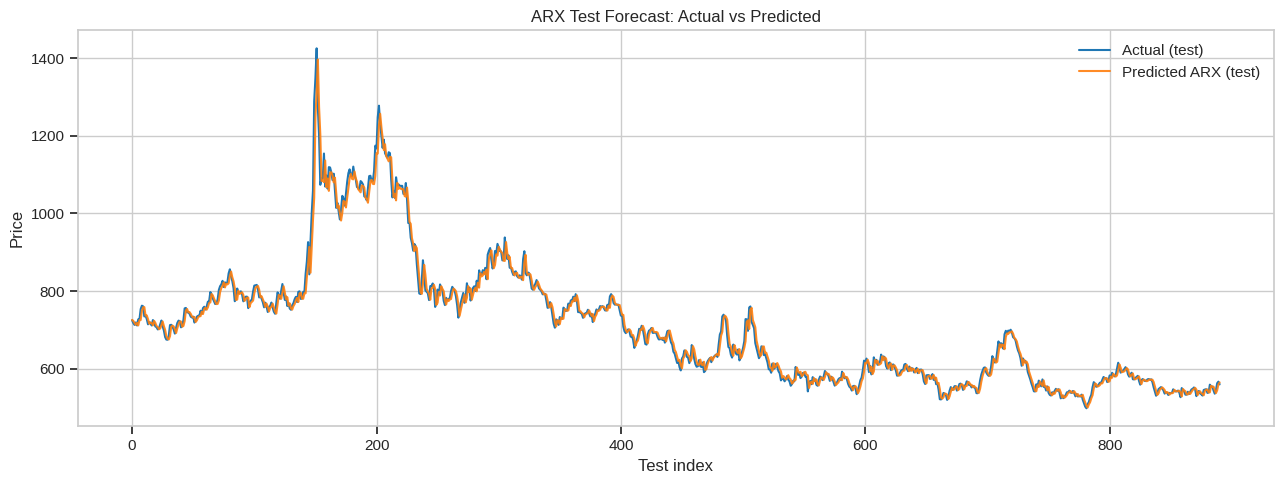

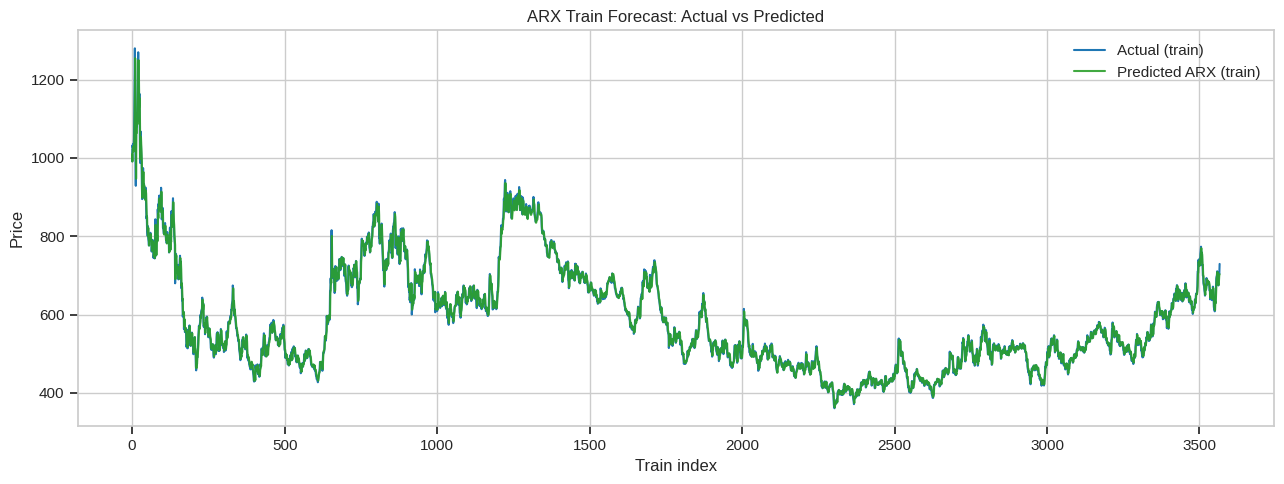

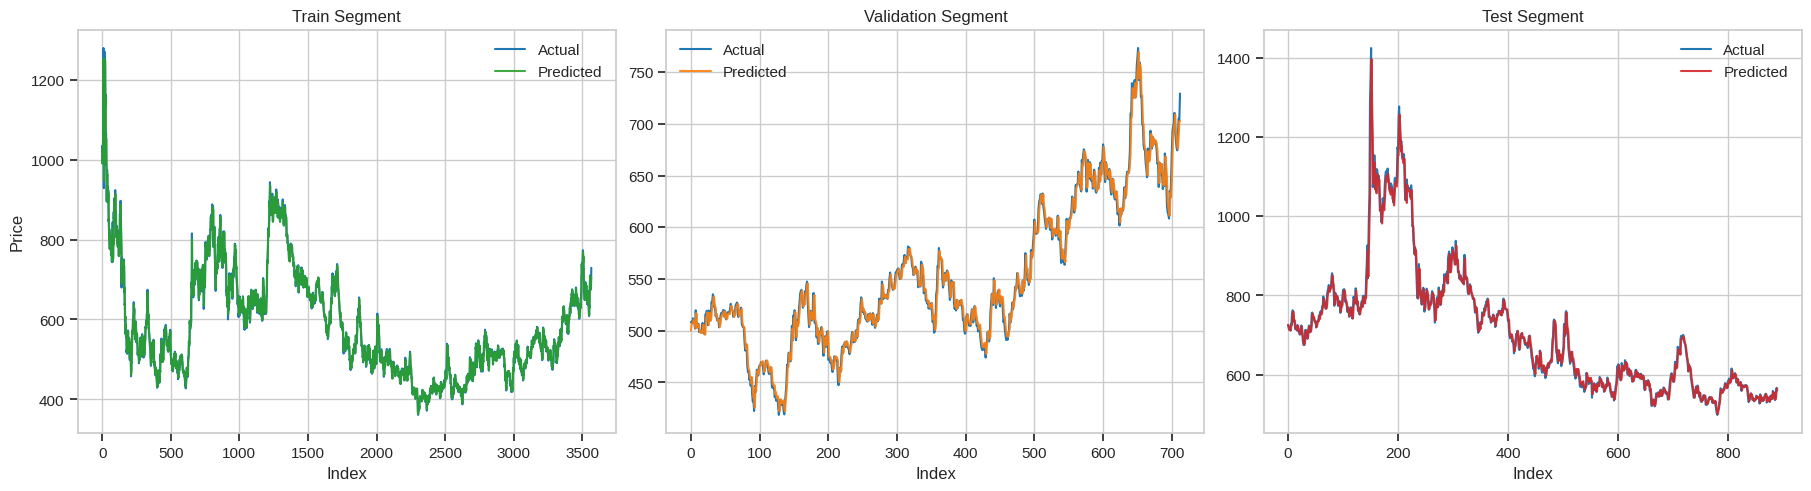

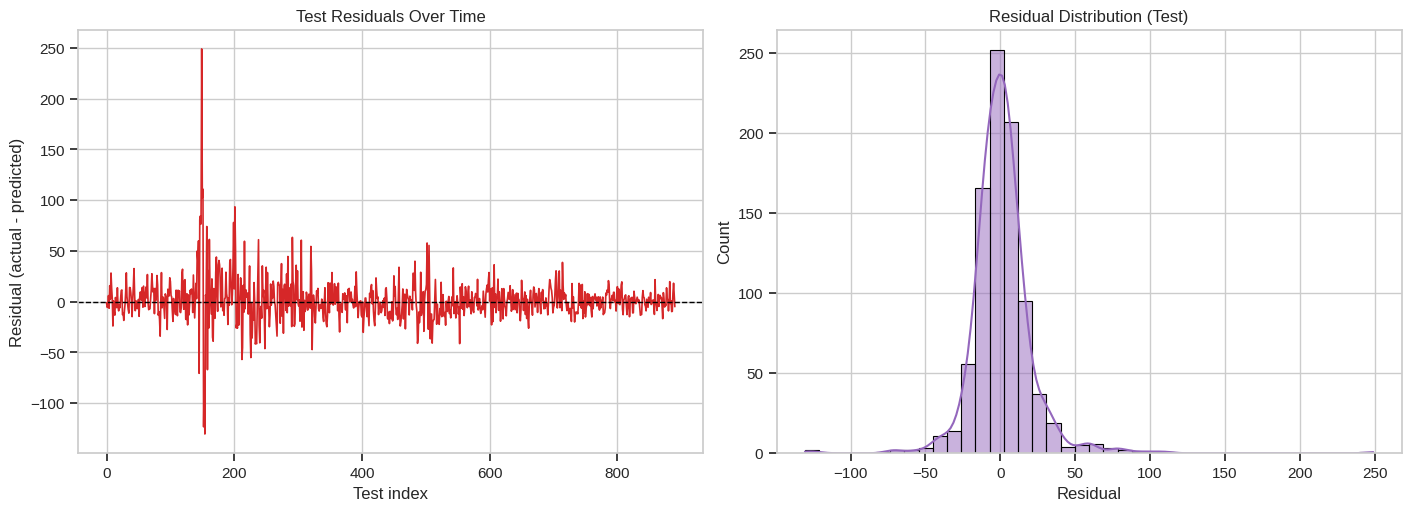

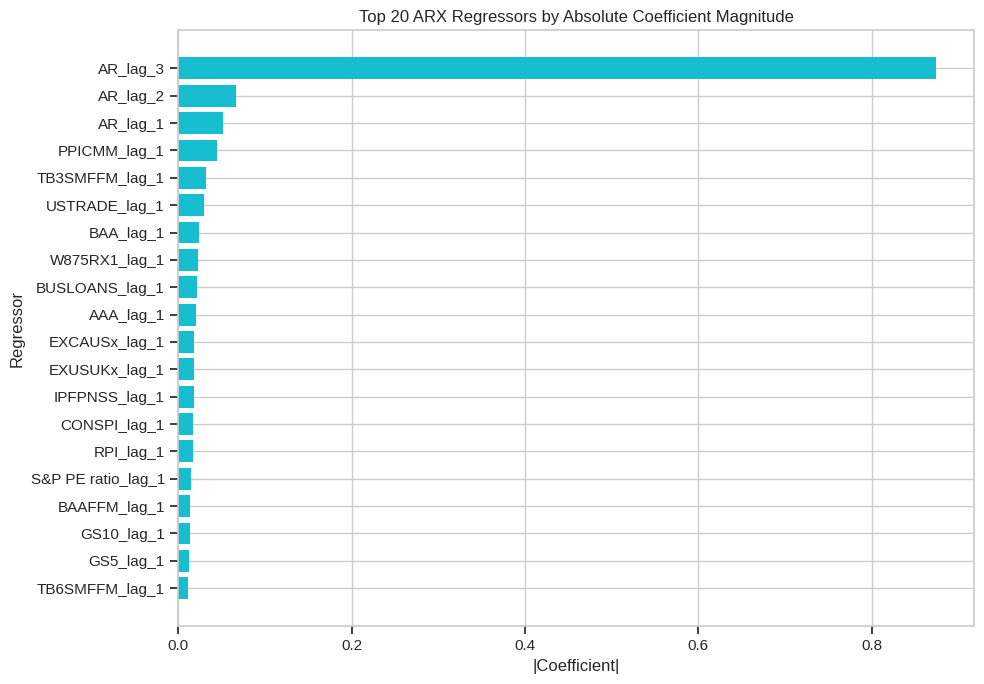

Top 20 coefficient drivers:


,regressor,abs_coef
2,AR_lag_3,0.874074
1,AR_lag_2,0.066923
0,AR_lag_1,0.051343
32,PPICMM_lag_1,0.045176
21,TB3SMFFM_lag_1,0.031716
8,USTRADE_lag_1,0.030184
20,BAA_lag_1,0.024492
4,W875RX1_lag_1,0.022829
9,BUSLOANS_lag_1,0.021751
19,AAA_lag_1,0.020676


In [10]:
# ============================================================
# Train final model on full training set using best config
# ============================================================

best_model = ARXForecastModel(
    task_type="regression",
    ar_lags=int(best_cfg["ar_lags"]),
    exog_lags=int(best_cfg["exog_lags"]),
    alpha=float(best_cfg["alpha"]),
    n_exog_features=len(FRED_FEATURES),
)
best_model.fit(X_train, y_train)

y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
y_test_pred = best_model.predict(X_test)
final_metrics = best_model.evaluate(X_test, y_test)

print("\nFinal ARX test metrics:")
for k, v in final_metrics.items():
    suffix = "%" if k == "mape" else ""
    print(f"  {k.upper():>6}: {v:.6f}{suffix}")

comparison_df = pd.DataFrame([
    {"model": "Naive Persistence", **naive_metrics},
    {"model": "ARX (best)", **final_metrics},
])

print("\nNaive vs ARX on test:")
display(comparison_df)


# ============================================================
# Graph 1: Actual vs Predicted (test)
# ============================================================

plt.figure(figsize=(13, 5))
plt.plot(y_test, label="Actual (test)", color="tab:blue")
plt.plot(y_test_pred, label="Predicted ARX (test)", color="tab:orange", alpha=0.9)
plt.title("ARX Test Forecast: Actual vs Predicted")
plt.xlabel("Test index")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Graph 2: Actual vs Predicted (train)
# ============================================================

plt.figure(figsize=(13, 5))
plt.plot(y_train, label="Actual (train)", color="tab:blue")
plt.plot(y_train_pred, label="Predicted ARX (train)", color="tab:green", alpha=0.9)
plt.title("ARX Train Forecast: Actual vs Predicted")
plt.xlabel("Train index")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Graph 3: Train / Validation / Test comparison panel
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

axes[0].plot(y_train, label="Actual", color="tab:blue")
axes[0].plot(y_train_pred, label="Predicted", color="tab:green", alpha=0.9)
axes[0].set_title("Train Segment")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Price")
axes[0].legend(loc="best")

axes[1].plot(y_val, label="Actual", color="tab:blue")
axes[1].plot(y_val_pred, label="Predicted", color="tab:orange", alpha=0.9)
axes[1].set_title("Validation Segment")
axes[1].set_xlabel("Index")
axes[1].legend(loc="best")

axes[2].plot(y_test, label="Actual", color="tab:blue")
axes[2].plot(y_test_pred, label="Predicted", color="tab:red", alpha=0.9)
axes[2].set_title("Test Segment")
axes[2].set_xlabel("Index")
axes[2].legend(loc="best")

plt.show()


# ============================================================
# Graph 4: Residual diagnostics
# ============================================================

residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].plot(residuals, color="tab:red", linewidth=1.2)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Test Residuals Over Time")
axes[0].set_xlabel("Test index")
axes[0].set_ylabel("Residual (actual - predicted)")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color="tab:purple")
axes[1].set_title("Residual Distribution (Test)")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.show()


# ============================================================
# Graph 5: Coefficient importance (absolute magnitude)
# ============================================================

# Rebuild regressor names for interpretability
ar_names = [f"AR_lag_{i}" for i in range(1, best_model.ar_lags + 1)]
exog_names = []
for lag in range(1, best_model.exog_lags + 1):
    for feat in FRED_FEATURES:
        exog_names.append(f"{feat}_lag_{lag}")

regressor_names = ar_names + exog_names
coef_abs = np.abs(best_model.coef_)

coef_df = pd.DataFrame({"regressor": regressor_names, "abs_coef": coef_abs})
coef_df = coef_df.sort_values("abs_coef", ascending=False).head(20).sort_values("abs_coef")

plt.figure(figsize=(10, 7))
plt.barh(coef_df["regressor"], coef_df["abs_coef"], color="tab:cyan")
plt.title("Top 20 ARX Regressors by Absolute Coefficient Magnitude")
plt.xlabel("|Coefficient|")
plt.ylabel("Regressor")
plt.tight_layout()
plt.show()

print("Top 20 coefficient drivers:")
display(coef_df.sort_values("abs_coef", ascending=False))

## Interpretation notes (to include in lab notes)

### 1) Price and macro-feature plots

- The wheat series shows distinct trend/regime shifts and volatility periods, motivating lag-based modeling.
- Normalized macro features evolve more smoothly than daily price, which supports using lagged exogenous structure in ARX.

### 2) Correlation bar chart

- The top correlated features provide a first-pass signal of which macro variables can be informative.
- Correlation does **not** imply causality, but it helps prioritize candidate exogenous inputs.

### 3) Train-test split chart

- The split is strictly chronological, so the model predicts future windows from past windows only.
- This is more realistic than random shuffling for financial/economic forecasting.

### 4) Actual vs Predicted (test)

- If ARX tracks turning points and local levels closely, the specification captures useful lag structure.
- Persistent lag or under/over-shoot indicates potential misspecification (insufficient lags, nonlinearity, or regime effects).

### 5) Residual diagnostics

- Residuals centered near zero with limited structure suggest better calibration.
- Heavy tails or visible residual autocorrelation imply remaining dynamics not captured by linear ARX.

### 6) Coefficient importance

- Large AR lag coefficients indicate strong dependence on recent price history.
- Large exogenous-lag coefficients reveal macro drivers with stronger linear contribution.

## Quick conclusion template

After execution, summarize using your numbers:

- Best ARX config: `(ar_lags=?, exog_lags=?, alpha=?)`
- Test RMSE/MAE/MAPE/MASE/RRMSE/R2: `...`
- Naive baseline vs ARX: `ARX is better/worse by ...`
- Main takeaway: `which lag block (AR vs exogenous) appears more influential and why`.

In [ ]:
# ============================================================
# Save/load round trip check
# ============================================================

MODEL_DIR = Path.cwd() / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "week1_arx.pkl"

best_model.save(MODEL_PATH)
print(f"Saved model to: {MODEL_PATH}")

loaded_model = ARXForecastModel()
loaded_model.load(MODEL_PATH)
loaded_pred = loaded_model.predict(X_test)

max_abs_diff = float(np.max(np.abs(y_test_pred - loaded_pred)))
print(f"Max |pred(original)-pred(loaded)|: {max_abs_diff:.12f}")

assert np.allclose(y_test_pred, loaded_pred), "Loaded model predictions mismatch."
print("Save/load integrity check passed.")

---

# Part 2: Next-Day Binary Classification

This section adapts the ARX (Autoregressive with eXogenous inputs) model
for **binary classification** — predicting whether the wheat futures price will move
**up (+1)** or **down (0)** on the next trading day.

**Pipeline (per assignment specification):**

1. Load raw FRED-MD vintage and apply **t-code stationarity transformations** to each
   of the 31 macro variables.
2. Account for the **one-month reporting delay** (shift macro dates forward by one month).
3. **Forward-fill** monthly macro data to daily frequency.
4. Input features: **30 lagged daily closing prices** (t−1 … t−30) +
   **31 t-code-transformed macro variables**. No additional indicators.
5. Target: next-day price direction (binary).
6. **StandardScaler fit on training data only** per CV fold (no data leakage).
7. **5-fold expanding-window time-series cross-validation** (TimeSeriesSplit).
8. Evaluation: Accuracy, Precision, Recall, Confusion Matrix, F1-score, ROC-AUC.

The ARX classifier uses **logistic regression** with the same regressor matrix
construction (AR price lags + exogenous macro lags) as the regression ARX.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns

print("Classification imports loaded.")

## Load raw FRED-MD and apply t-code stationarity transformations

Each FRED-MD variable has a transformation code (t-code) indicating how to make it
stationary. The codes are read directly from the second row of the vintage CSV.

| T-Code | Transformation | Formula |
|--------|----------------|---------|
| 1 | Level (no change) | $x_t$ |
| 2 | First difference | $x_t - x_{t-1}$ |
| 3 | Second difference | $(x_t - x_{t-1}) - (x_{t-1} - x_{t-2})$ |
| 4 | Log | $\ln(x_t)$ |
| 5 | Log first difference | $\ln(x_t) - \ln(x_{t-1})$ |
| 6 | Log second difference | $(\ln x_t - \ln x_{t-1}) - (\ln x_{t-1} - \ln x_{t-2})$ |

In [ ]:
fred_md_path = '/content/drive/MyDrive/Quants /FredMD_Dataset/2025-10-MD.csv'

tcodes_row = pd.read_csv(fred_md_path, nrows=1)
fred_raw = pd.read_csv(fred_md_path, skiprows=[1])
fred_raw['sasdate'] = pd.to_datetime(fred_raw['sasdate'], format='%m/%d/%Y')
fred_raw = fred_raw.set_index('sasdate').sort_index()

features_31 = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE",
    "USTRADE", "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio",
    "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "GS5", "GS10",
    "AAA", "BAA", "TB3SMFFM", "TB6SMFFM", "T1YFFM",
    "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx",
]

tcode_map = {}
for col in features_31:
    tcode_map[col] = int(float(tcodes_row[col].values[0]))

print("T-codes for the 31 required variables:")
for col, tc in tcode_map.items():
    print(f"  {col:20s} -> t-code {tc}")

In [ ]:
def apply_tcode(series, tcode):
    if tcode == 1:
        return series
    elif tcode == 2:
        return series.diff()
    elif tcode == 3:
        return series.diff().diff()
    elif tcode == 4:
        return np.log(series.clip(lower=1e-10))
    elif tcode == 5:
        return np.log(series.clip(lower=1e-10)).diff()
    elif tcode == 6:
        return np.log(series.clip(lower=1e-10)).diff().diff()
    elif tcode == 7:
        return (series / series.shift(1) - 1).diff()
    else:
        return series

fred_selected = fred_raw[features_31].copy()
fred_selected = fred_selected.apply(pd.to_numeric, errors='coerce')

for col in features_31:
    fred_selected[col] = apply_tcode(fred_selected[col], tcode_map[col])

fred_transformed = fred_selected.dropna()
fred_transformed = fred_transformed.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Raw FRED-MD shape:            {fred_raw[features_31].shape}")
print(f"After t-code transformation:  {fred_transformed.shape}")
print(f"Date range: {fred_transformed.index.min().date()} to {fred_transformed.index.max().date()}")
fred_transformed.head()

### Apply one-month reporting delay and forward-fill to daily

FRED-MD data is released with a one-month lag: on any given day in month $m$, only
data through month $m-1$ is available. We shift the macro dates forward by one month,
then forward-fill to create a daily series aligned with the price data.

In [ ]:
df_macro_cls = fred_transformed.copy()
df_macro_cls.index = df_macro_cls.index + pd.DateOffset(months=1)

start = df_macro_cls.index.min()
end = df_macro_cls.index.max() + pd.offsets.MonthEnd(0)
all_days = pd.date_range(start, end, freq='D')
df_macro_cls = df_macro_cls.reindex(all_days).ffill()

print(f"Daily macro features shape: {df_macro_cls.shape}")
print(f"Date range: {df_macro_cls.index.min().date()} to {df_macro_cls.index.max().date()}")
df_macro_cls.head()

### Merge with daily wheat prices and construct classification dataset

Features at each time step: **daily closing price + 31 t-code-transformed macro
variables** = 32 features.

- **Rolling window**: 30-day lookback (t−30 to t−1).
- **Target**: price direction on day t — **1** if price went up, **0** if down.

In [ ]:
df_cls = df_macro_cls.join(df_price, how='inner')
df_cls = df_cls['2008-01-01':]

cols_order = [c for c in df_cls.columns if c != 'Price'] + ['Price']
df_cls = df_cls[cols_order]

print(f"Classification dataset: {df_cls.shape}")
print(f"Date range: {df_cls.index.min().date()} to {df_cls.index.max().date()}")
print(f"Columns ({df_cls.shape[1]}): {list(df_cls.columns)}")
df_cls.head()

In [ ]:
lookback_cls = 30
price_col_idx = df_cls.columns.get_loc('Price')
data_cls = df_cls.values

X_cls, y_cls = [], []
for i in range(lookback_cls, len(data_cls)):
    X_cls.append(data_cls[i - lookback_cls : i])
    y_cls.append(1 if data_cls[i, price_col_idx] > data_cls[i - 1, price_col_idx] else 0)

X_cls = np.array(X_cls)
y_cls = np.array(y_cls)

print(f"X_cls shape: {X_cls.shape}  (samples, lookback, features)")
print(f"y_cls shape: {y_cls.shape}")
print(f"Class distribution: Up={y_cls.sum()} ({y_cls.mean():.2%}), "
      f"Down={len(y_cls)-y_cls.sum()} ({1-y_cls.mean():.2%})")

### Chronological train / test split

Time-based split (80 % train, 20 % test). No shuffling — the test set is strictly
in the future relative to training data.

In [ ]:
split_cls = int(len(X_cls) * 0.8)
X_train_cls = X_cls[:split_cls]
y_train_cls = y_cls[:split_cls]
X_test_cls  = X_cls[split_cls:]
y_test_cls  = y_cls[split_cls:]

target_dates_cls = df_cls.index[lookback_cls:]
train_dates_cls  = target_dates_cls[:split_cls]
test_dates_cls   = target_dates_cls[split_cls:]

print(f"Train: {X_train_cls.shape[0]} samples "
      f"({train_dates_cls[0].date()} to {train_dates_cls[-1].date()})")
print(f"Test:  {X_test_cls.shape[0]} samples "
      f"({test_dates_cls[0].date()} to {test_dates_cls[-1].date()})")
print(f"\nTrain class dist: Up={y_train_cls.sum()} ({y_train_cls.mean():.2%}), "
      f"Down={len(y_train_cls)-y_train_cls.sum()} ({1-y_train_cls.mean():.2%})")
print(f"Test  class dist: Up={y_test_cls.sum()} ({y_test_cls.mean():.2%}), "
      f"Down={len(y_test_cls)-y_test_cls.sum()} ({1-y_test_cls.mean():.2%})")

## ARX Binary Classifier

Same ARX regressor-matrix construction as Part 1:
- **AR lags**: last `ar_lags` daily closing prices from the lookback window.
- **Exogenous lags**: last `exog_lags` days of the 31 macro features, flattened.

The combined feature vector is fed into **logistic regression** (via `sklearn`)
with balanced class weights instead of the ridge closed-form used in regression.

In [ ]:
from sklearn.linear_model import LogisticRegression

class ARXClassifier(BaseForecastModel):
    """
    ARX-style binary classifier for next-day wheat futures price direction.
    Constructs the same regressor matrix as ARXForecastModel (AR price lags +
    exogenous macro lags), then applies logistic regression.
    """

    def __init__(
        self,
        task_type: str = 'classification',
        ar_lags: int = 5,
        exog_lags: int = 3,
        alpha: float = 1.0,
        n_exog_features: int = 31,
    ):
        super().__init__(
            task_type=task_type,
            ar_lags=ar_lags,
            exog_lags=exog_lags,
            alpha=alpha,
            n_exog_features=n_exog_features,
        )
        self.ar_lags = ar_lags
        self.exog_lags = exog_lags
        self.alpha = alpha
        self.n_exog_features = n_exog_features

        self.clf_ = None
        self.x_scaler_ = None

    def _build_regressor_matrix(self, X_3d_scaled: np.ndarray) -> np.ndarray:
        price_lags = X_3d_scaled[:, -self.ar_lags:, -1]
        exog_lags = X_3d_scaled[:, -self.exog_lags:, :self.n_exog_features]
        exog_flat = exog_lags.reshape(X_3d_scaled.shape[0], -1)
        return np.concatenate([price_lags, exog_flat], axis=1)

    def _scale_X(self, X_3d: np.ndarray, fit: bool = False) -> np.ndarray:
        n_features = X_3d.shape[2]
        if fit:
            self.x_scaler_ = StandardScaler()
            X_scaled = self.x_scaler_.fit_transform(X_3d.reshape(-1, n_features))
        else:
            X_scaled = self.x_scaler_.transform(X_3d.reshape(-1, n_features))
        return X_scaled.reshape(X_3d.shape)

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        X_s = self._scale_X(X_train, fit=True)
        Z = self._build_regressor_matrix(X_s)

        C_val = 1.0 / max(self.alpha, 1e-8)
        self.clf_ = LogisticRegression(
            C=C_val,
            class_weight='balanced',
            max_iter=1000,
            solver='lbfgs',
            random_state=42,
        )
        self.clf_.fit(Z, y_train)

        train_preds = self.clf_.predict(Z)
        print("=== Train set performance ===")
        print(f"  Accuracy: {accuracy_score(y_train, train_preds):.6f}")
        print(f"  F1:       {f1_score(y_train, train_preds, zero_division=0):.6f}")
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if self.clf_ is None:
            raise ValueError("Model not trained -- call fit() first.")
        X_s = self._scale_X(X, fit=False)
        Z = self._build_regressor_matrix(X_s)
        return self.clf_.predict_proba(Z)[:, 1]

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.predict_proba(X)

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray, threshold: float = 0.5):
        probs = self.predict_proba(X_test)
        preds = (probs >= threshold).astype(int)
        metrics = {
            'accuracy':  accuracy_score(y_test, preds),
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall':    recall_score(y_test, preds, zero_division=0),
            'f1':        f1_score(y_test, preds, zero_division=0),
        }
        try:
            metrics['auc_roc'] = roc_auc_score(y_test, probs)
        except ValueError:
            metrics['auc_roc'] = 0.5
        return metrics

    def save(self, filepath: str):
        payload = {
            'clf': self.clf_,
            'x_scaler': self.x_scaler_,
            'hyperparameters': self.hyperparameters,
        }
        with open(filepath, 'wb') as f:
            pickle.dump(payload, f)

    def load(self, filepath: str):
        with open(filepath, 'rb') as f:
            payload = pickle.load(f)
        self.clf_ = payload['clf']
        self.x_scaler_ = payload['x_scaler']
        hp = payload['hyperparameters']
        self.hyperparameters = hp
        self.ar_lags = hp['ar_lags']
        self.exog_lags = hp['exog_lags']
        self.alpha = hp['alpha']
        self.n_exog_features = hp['n_exog_features']
        return self

print("ARXClassifier defined.")

### 5-fold expanding-window cross-validation (classification)

For each fold:
1. **StandardScaler is fit on training data only** and applied to the validation fold.
2. **Balanced class weights** are built into the logistic regression.
3. All classification metrics are recorded per fold and averaged.

In [ ]:
def cv_arx_cls(X_train, y_train, ar_lags=5, exog_lags=3, alpha=1.0):
    """5-fold expanding-window CV for ARX classification; returns averaged metrics."""
    tscv = TimeSeriesSplit(n_splits=5)
    n_exog = X_train.shape[2] - 1

    fold_metrics = {
        'accuracy': [], 'precision': [], 'recall': [],
        'f1': [], 'auc_roc': [], 'val_loss': [],
    }
    all_val_probs, all_val_true = [], []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = ARXClassifier(
            ar_lags=ar_lags, exog_lags=exog_lags,
            alpha=alpha, n_exog_features=n_exog,
        )

        X_s_tr = model._scale_X(X_tr, fit=True)
        Z_tr = model._build_regressor_matrix(X_s_tr)

        C_val = 1.0 / max(alpha, 1e-8)
        model.clf_ = LogisticRegression(
            C=C_val, class_weight='balanced',
            max_iter=1000, solver='lbfgs', random_state=42,
        )
        model.clf_.fit(Z_tr, y_tr)

        X_s_val = model._scale_X(X_val, fit=False)
        Z_val = model._build_regressor_matrix(X_s_val)
        val_probs = model.clf_.predict_proba(Z_val)[:, 1]
        val_preds = (val_probs >= 0.5).astype(int)

        from sklearn.metrics import log_loss
        fold_metrics['val_loss'].append(log_loss(y_val, val_probs))

        fold_metrics['accuracy'].append(accuracy_score(y_val, val_preds))
        fold_metrics['precision'].append(
            precision_score(y_val, val_preds, zero_division=0))
        fold_metrics['recall'].append(
            recall_score(y_val, val_preds, zero_division=0))
        fold_metrics['f1'].append(
            f1_score(y_val, val_preds, zero_division=0))
        try:
            fold_metrics['auc_roc'].append(roc_auc_score(y_val, val_probs))
        except ValueError:
            fold_metrics['auc_roc'].append(0.5)

        all_val_probs.extend(val_probs)
        all_val_true.extend(y_val)

        print(f"  Fold {fold+1}: "
              f"Acc={fold_metrics['accuracy'][-1]:.4f}  "
              f"F1={fold_metrics['f1'][-1]:.4f}  "
              f"AUC={fold_metrics['auc_roc'][-1]:.4f}")

    avg_metrics = {k: np.mean(v) for k, v in fold_metrics.items()}
    return avg_metrics, np.array(all_val_true), np.array(all_val_probs)

## Default Hyperparameters — Training and Evaluation

Train the ARX classifier with **default** hyperparameters
(`ar_lags=5, exog_lags=3, alpha=1.0`)
and evaluate via 5-fold expanding-window cross-validation.

In [ ]:
default_cls_metrics, default_val_true, default_val_probs = cv_arx_cls(
    X_train_cls, y_train_cls,
    ar_lags=5, exog_lags=3, alpha=1.0,
)

print("\n=== Default CV Classification Metrics (5-fold avg) ===")
for k, v in default_cls_metrics.items():
    print(f"  {k:12s}: {v:.6f}")

In [ ]:
default_val_preds = (default_val_probs >= 0.5).astype(int)

print("=== Default CV — Confusion Matrix (aggregated over all folds) ===")
print(confusion_matrix(default_val_true, default_val_preds))
print()
print(classification_report(
    default_val_true, default_val_preds, target_names=['Down', 'Up']))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cm = confusion_matrix(default_val_true, default_val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Default CV — Confusion Matrix')
plt.tight_layout()
plt.show()

## Hyperparameter Grid Search (Classification)

Same grid search approach as Part 1 — sweep over `ar_lags`, `exog_lags`, and `alpha`.
The objective is to **maximise the average F1-score** across 5-fold CV.

In [ ]:
from itertools import product

cls_search_space = {
    'ar_lags':   [3, 5, 7, 10],
    'exog_lags': [1, 3, 5],
    'alpha':     [0.01, 0.1, 1.0, 5.0],
}

cls_combos = list(product(
    cls_search_space['ar_lags'],
    cls_search_space['exog_lags'],
    cls_search_space['alpha'],
))

cls_results = []
for ar_lags, exog_lags, alpha in tqdm(cls_combos, desc="ARX Cls grid search"):
    avg_m, _, _ = cv_arx_cls(
        X_train_cls, y_train_cls,
        ar_lags=ar_lags, exog_lags=exog_lags, alpha=alpha,
    )
    row = {
        'ar_lags': ar_lags,
        'exog_lags': exog_lags,
        'alpha': alpha,
        **{f'cv_{k}': v for k, v in avg_m.items()},
    }
    cls_results.append(row)

cls_results_df = pd.DataFrame(cls_results).sort_values('cv_f1', ascending=False).reset_index(drop=True)
print("Top 10 configurations by CV F1-score:")
display(cls_results_df.head(10))

best_cls_cfg = cls_results_df.iloc[0]
print("\nSelected configuration:")
print(best_cls_cfg[['ar_lags', 'exog_lags', 'alpha', 'cv_accuracy', 'cv_f1', 'cv_auc_roc']])

In [ ]:
best_ar   = int(best_cls_cfg['ar_lags'])
best_exog = int(best_cls_cfg['exog_lags'])
best_alpha = float(best_cls_cfg['alpha'])

grid_cls_metrics, grid_val_true, grid_val_probs = cv_arx_cls(
    X_train_cls, y_train_cls,
    ar_lags=best_ar, exog_lags=best_exog, alpha=best_alpha,
)

print("\n=== Grid Search CV Classification Metrics (5-fold avg) ===")
for k, v in grid_cls_metrics.items():
    print(f"  {k:12s}: {v:.6f}")

In [ ]:
grid_val_preds = (grid_val_probs >= 0.5).astype(int)

print("=== Grid Search CV — Confusion Matrix (aggregated over all folds) ===")
print(confusion_matrix(grid_val_true, grid_val_preds))
print()
print(classification_report(
    grid_val_true, grid_val_preds, target_names=['Down', 'Up']))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cm = confusion_matrix(grid_val_true, grid_val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Grid Search CV — Confusion Matrix')
plt.tight_layout()
plt.show()

## Final Evaluation on Held-Out Test Set

Train the final ARX classifier on the **entire training set** using the best
grid-search hyperparameters, then evaluate on the chronologically held-out test set.

In [ ]:
final_cls = ARXClassifier(
    ar_lags=best_ar, exog_lags=best_exog,
    alpha=best_alpha, n_exog_features=31,
)
final_cls.fit(X_train_cls, y_train_cls)

test_probs = final_cls.predict_proba(X_test_cls)
test_preds = (test_probs >= 0.5).astype(int)

print("\n=== Final Test Set Results ===")
print(f"  Accuracy:  {accuracy_score(y_test_cls, test_preds):.6f}")
print(f"  Precision: {precision_score(y_test_cls, test_preds, zero_division=0):.6f}")
print(f"  Recall:    {recall_score(y_test_cls, test_preds, zero_division=0):.6f}")
print(f"  F1-score:  {f1_score(y_test_cls, test_preds, zero_division=0):.6f}")
try:
    print(f"  AUC-ROC:   {roc_auc_score(y_test_cls, test_probs):.6f}")
except ValueError:
    print("  AUC-ROC:   N/A")
print()
print(confusion_matrix(y_test_cls, test_preds))
print()
print(classification_report(
    y_test_cls, test_preds, target_names=['Down', 'Up']))

### Visualizations

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_test = confusion_matrix(y_test_cls, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Test Set — Confusion Matrix')

try:
    fpr, tpr, _ = roc_curve(y_test_cls, test_probs)
    auc_val = roc_auc_score(y_test_cls, test_probs)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC (AUC = {auc_val:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--',
                 label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Test Set — ROC Curve')
    axes[1].legend(loc='lower right')
except ValueError:
    axes[1].text(0.5, 0.5, 'ROC unavailable', ha='center', va='center')

plt.tight_layout()
plt.show()

In [ ]:
rolling_correct = pd.Series(
    (test_preds == y_test_cls).astype(int),
    index=test_dates_cls,
)
rolling_acc = rolling_correct.rolling(window=50, min_periods=10).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_acc.index, rolling_acc.values, color='steelblue', lw=1.5)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7,
           label='Random baseline (50%)')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Accuracy (50-day)')
ax.set_title('Test Set — Rolling Classification Accuracy Over Time')
ax.legend()
plt.tight_layout()
plt.show()

## Classification — Model Comparison

In [ ]:
def _safe_auc(y_true, y_probs):
    try:
        return roc_auc_score(y_true, y_probs)
    except ValueError:
        return 0.5

cls_comparison = pd.DataFrame([
    {
        'Model': 'ARX (Default CV)',
        'Accuracy':  default_cls_metrics['accuracy'],
        'Precision': default_cls_metrics['precision'],
        'Recall':    default_cls_metrics['recall'],
        'F1':        default_cls_metrics['f1'],
        'AUC-ROC':   default_cls_metrics['auc_roc'],
    },
    {
        'Model': 'ARX (Grid Search CV)',
        'Accuracy':  grid_cls_metrics['accuracy'],
        'Precision': grid_cls_metrics['precision'],
        'Recall':    grid_cls_metrics['recall'],
        'F1':        grid_cls_metrics['f1'],
        'AUC-ROC':   grid_cls_metrics['auc_roc'],
    },
    {
        'Model': 'ARX (Final Test)',
        'Accuracy':  accuracy_score(y_test_cls, test_preds),
        'Precision': precision_score(y_test_cls, test_preds, zero_division=0),
        'Recall':    recall_score(y_test_cls, test_preds, zero_division=0),
        'F1':        f1_score(y_test_cls, test_preds, zero_division=0),
        'AUC-ROC':   _safe_auc(y_test_cls, test_probs),
    },
])

cls_comparison = cls_comparison.set_index('Model')
cls_comparison.style \
    .highlight_max(subset=['Accuracy', 'F1', 'AUC-ROC'], color='#d4edda') \
    .format('{:.6f}')